In [4]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [7]:
from scipy.io import loadmat

# Load training data
train_data = loadmat('4a/train_32x32.mat')

# Load testing data
test_data = loadmat('4a/test_32x32.mat')

In [8]:
X_train = train_data['X']
y_train = train_data['y']

X_test = test_data['X']
y_test = test_data['y']

In [9]:
print("Train images shape:", X_train.shape)
print("Train labels shape:", y_train.shape)

print("Test images shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Train images shape: (32, 32, 3, 73257)
Train labels shape: (73257, 1)
Test images shape: (32, 32, 3, 26032)
Test labels shape: (26032, 1)


In [10]:
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0

In [12]:
X_train = X_train.transpose((3, 0, 1, 2))
X_test = X_test.transpose((3, 0, 1, 2))

print("New shape:", X_train.shape)

New shape: (73257, 32, 32, 3)


In [13]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [15]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (73257, 32, 32, 3)
y_train: (73257, 10)


In [17]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(128, activation='relu'))

# Output Layer (10 digits)
model.add(layers.Dense(10, activation='softmax'))

In [18]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(X_train, y_train,epochs=10,validation_data=(X_test, y_test))

Epoch 1/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 97s 41ms/step - accuracy: 0.5514 - loss: 1.3242 - val_accuracy: 0.8612 - val_loss: 0.5007
Epoch 2/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.8732 - loss: 0.4357 - val_accuracy: 0.8860 - val_loss: 0.4072
Epoch 3/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 101s 44ms/step - accuracy: 0.9015 - loss: 0.3387 - val_accuracy: 0.8908 - val_loss: 0.3812
Epoch 4/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 86s 38ms/step - accuracy: 0.9125 - loss: 0.2955 - val_accuracy: 0.8931 - val_loss: 0.3815
Epoch 5/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 192s 84ms/step - accuracy: 0.9206 - loss: 0.2645 - val_accuracy: 0.8953 - val_loss: 0.3674
Epoch 6/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9287 - loss: 0.2378 - val_accuracy: 0.8958 - val_loss: 0.3730
Epoch 7/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 158s 69ms/step - accuracy: 0.9338 - loss: 0.2190 - val_accuracy: 0.9063 - val_loss: 0.3438
Epoch 8/10
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 96s 42ms/step - accuracy: 0.939

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

814/814 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8981 - loss: 0.4152
Test Accuracy: 0.9011601209640503


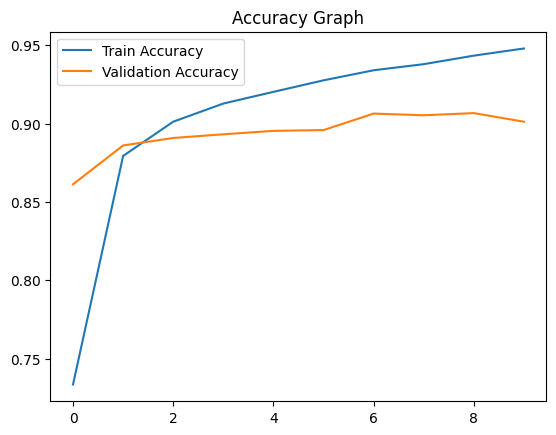

In [26]:
#acc visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

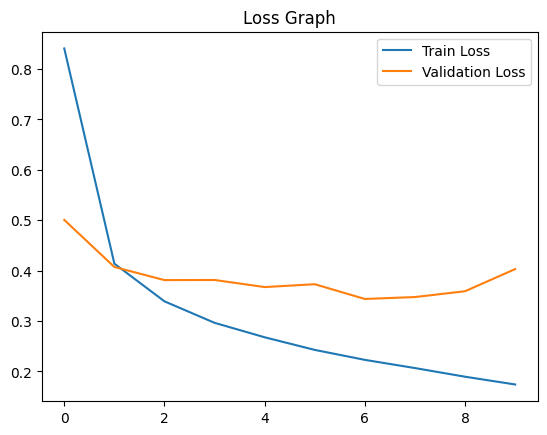

In [27]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()